## AI/ML Techniques for the Statistical Inference:


### Use of Neural Network Architures in Bayesian Parameter Inference

#### Understanding the Training Dataset

<img src='data/images/BNN/presentation_material/Simulation_model.jpg'>

##### [ReionYuga](https://github.com/rajeshmondal18/ReionYuga) is a semi-Numerical simulation code for simulating 21-cm signal from IGM. It has 3 input parameters:
* $\rm M_{(h,min)}$: Minimum mass of the halos capable of ionizing the IGM
* $\rm N_{ion}$: Propotionality constant that gives the number of ionizing photos for given halo
* $\rm R_{mfp}$: Mean free path of the ionizing photon

##### Below is an example of the 21-cm brightness temperature field generated by ReionYuga simulation.

* $z = 7, \:$ $\rm M_{{(h,min)}} = 508.95 \times 10^{{8}}\;M_\odot ,\:$ $\rm N_{{ion}} = 171.58,\:$ $\rm R_{{max}} = 8.04 \:Mpc $

<img src='data/HI_map.png'>

In [1]:
import numpy as np
from my_code import PlotPs

/home/yash/miniconda3/envs/tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
parameters = np.loadtxt('./data/Parameters.txt', skiprows=1)

xHI = parameters[:,0]
input_params = parameters[:,1:]

k_values = np.loadtxt('./data/K_vals.txt',skiprows=1)
delta_PS = np.loadtxt('./data/Power_Spectrum_Normalised.txt',skiprows=1)

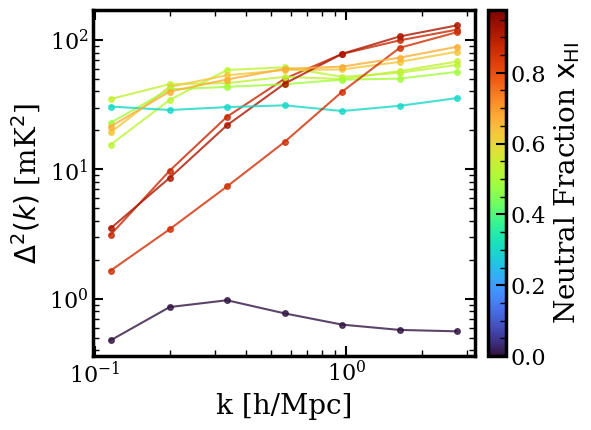

In [3]:
# Plotting the power spectrum for different xHI values

PlotPs(k_values, delta_PS, xHI, num=10)   


## Artificial Neural Network (ANN) as an Emulator

<img src="data/images/BNN/neurons.png" alt="Neurons" width="500">

- The very fundamental unit of the neural network is **Neuron** (sometimes also called **Node**), that is inspired from the biological neurons in our brain.
- These multiple neurons make a layer and the "network" is made up of multiple layers which are interconneted. 
- Aritficial Neural Network (ANN) is a typical expample of the Deep Neural Network (DNN) which has multiple layers (thus it's called 'deep').

<img src="data/images/BNN/presentation_material/training_of_ann.png" alt="Training of ANN" width="1200" height="550">

### Creating Training Dataset

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch

from my_code.ann import TrainANN

In [4]:
x_scalar = StandardScaler()
x_input = x_scalar.fit_transform(input_params)

In [5]:
train_num = 5600
input_train = input_params[:train_num]
delta_PS_train = delta_PS[:train_num]

x_train, x_val, y_train, y_val = train_test_split(input_train, delta_PS_train, test_size=0.2, random_state=67)

In [6]:
training_data = [x_train, y_train]
validation_data = [x_val, y_val]

### Training an ANN

In [ ]:
train_loss, val_loss = TrainANN(training_data, validation_data, hidden_layers=[64,128,128,64] )

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.ylim(0, 500)
plt.legend()
plt.show()

### Using ANN for Prediction

In [ ]:
model = torch.load('./ANN_model/best_model.pth', weights_only=True)
model["epoch"]
model["loss"]

In [ ]:
from my_code.ann import ANN

In [ ]:
ann_model = ANN().to('cuda')
ann_model.load_state_dict(model["model_state_dict"])
ann_model.eval()

In [ ]:
x_test = x_val[:5]
y_test = y_val[:5]

x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to('cuda')
with torch.no_grad():
    y_pred_tensor = ann_model(x_test_tensor)

y_pred = y_pred_tensor.cpu().numpy()
print("Predicted Power Spectrum:")
print(y_pred)
print("True Power Spectrum:")
print(y_test)

# Plotting the predicted vs true power spectrum for the test set

for i in range(len(x_test)):
    plt.figure(figsize=(6, 4.5))
    plt.plot(k_values, y_test[i], label=f'True', linestyle='--', marker='o')
    plt.plot(k_values, y_pred[i], label=f'Predicted', linestyle='-', marker='x')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('k [h/Mpc]')
    plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')
    plt.legend()
    plt.title("Neutral Fraction: {:.2f}".format(xHI[i]))
    plt.show()

In [ ]:
def ANN_model(input_params):
    input = x_scalar.transform([input_params].reshape(1, -1))
    input_tensor = torch.tensor(input, dtype=torch.float32).to('cuda')
    with torch.no_grad():
        output_tensor = ann_model(input_tensor)
    return output_tensor.cpu().numpy().reshape(-1)

## Bayesian Neural Network (BNN) as an Emulator

<img src="data/images/BNN/presentation_material/ANN_vs_BNN1.jpg" alt="ANN vs BNN" width="750" height="500">

### MCMC Method:

- We sample the the underlying ditribution of the weights and bias for the given training dataset.
- That way we learn the mean and variance of the each weight and biases of the network.
- Essentially, you are sampling from very high dimensional space, which makes this method computationally very costly.
- For this sampling we use the [NUTS (No U-Turn Sampling)](https://en.wikipedia.org/wiki/Hamiltonian_Monte_Carlo#No_U-Turn_Sampler) technique.

In [8]:
from my_code import TrainBNN, BNNPredict

In [ ]:
bnn_model_mcmc = TrainBNN(method="MCMC", training_data=training_data, hidden_layers=[16,16], num_samples=500, warmup_steps=200, path="MCMC_model")
posterior_samples = bnn_model_mcmc.train()

### Stochastic Variational Inference (SVI) Method:
    
- We try to get the probability ditribution of the weights conditioned on the training dataset.
- We use the Bayes' Theorem to get the target distribution, using Kullback-Leibler Divergence.
    

**Goal:** To understand the probability of the latent variables given dataset: $p(z|x)$.

- **Input dataset:** $x$
- **latent variable set:** $z$

**Variational Methods**

Using Bayes formula:
\begin{align*}
p(z|x) = \frac{p(z,x)}{p(x)}
\end{align*}

We use $p(x)$ which is \textbf{intractable}.

Consider a distribution $q$ with some distribution parameters $\theta$, which depends on the latent variables $z$, i.e., the distribution of latent variables given input data $q(z|x)$.

Now, our problem is to find $q(z|x)$ which describes $p(z|x)$ the best.

**Kullback-Leibler Divergence**

Given by:
\begin{align*}
D_{KL} &= D_{KL}[q(z|x)||p(z|x)]\\
&= \int q(z|x) \log \left[\frac{q(z|x)}{p(z|x)}\right] dz
\end{align*}

$D_{KL}$ is a distance measure for two distributions.
So, goal is to make this distance minimum.

**Note:** $D_{KL}$ is always positive.

**Problem:** Again $p(z|x)$ is also intractable. This is in fact what we need.

**Solution: Manipulating the KL Divergence**

Let's play with $D_{KL}$:

\begin{align*}
D_{KL}[q(z|x)||p(z|x)] &= \int q(z|x) \log \left[\frac{q(z|x)}{p(z|x)}\right] dz\\
&= \int q(z|x) \{\log [q(z|x)] - \log [p(z|x)]\} dz\\
&= E_q [\log q(z|x)] - E_q [\log p(z|x)]
\end{align*}

similar to $\int x f(x) dx = E[x]$:

\begin{align*}
D_{KL} &= E_q [\log q(z|x)] - E_q \left[\log \frac{p(z,x)}{p(x)}\right] \quad \text{[using Bayes]}\\
&= E_q [\log q(z|x)] - E_q [\log p(z,x) - \log p(x)]\\
&= E_q [\log q(z|x) - \log p(z,x)] + \log p(x)
\end{align*}

Rearranging:
\begin{align*}
\log p(x) = D_{KL} + E_q [\log p(z,x) - \log q(z|x)]
\end{align*}

Since $D_{KL} \geq 0$:
\begin{align*}
\log p(x) \geq E_q [\log p(z,x) - \log q(z|x)]
\end{align*}

So, it is called \textbf{Evidence Lower Bound (ELBO)}:

\begin{align*}
\text{ELBO}(q) &= E_q [\log p(z,x) - \log q(z|x)]\\
&= E_{q(z|x)} \left[\log \frac{p(z,x)}{q(z|x)}\right]
\end{align*}

**ELBO Decomposition**

Decompose it further:

\begin{align*}
\text{ELBO} &= E_q [\log p(z,x) - \log q(z|x)]\\
&= E_q [\log p(x|z)p(z) - \log q(z|x)]\\
&= E_q [\log p(x|z)] + E_q [\log p(z)] - E_q [\log q(z|x)]\\
&= E_q [\log p(x|z)] + E_q \left[\log \frac{p(z)}{q(z|x)}\right]\\
&= E_q [\log p(x|z)] + E_q [\log p(z) - \log q(z|x)]\\
&= E_q [\log p(x|z)] + \int q(z|x) \log \frac{p(z)}{q(z|x)} d(z)
\end{align*}

Therefore:
\begin{align*}
\boxed{\text{ELBO} = E_q [\log p(x|z)] - D_{KL} [q(z|x) || p(z)]}
\end{align*}

**Optimization Goal**

**Goal:** Maximize the ELBO

This involves:

- Maximizing the first term: $E_q [\log p(x|z)]$ (reconstruction term)
- Minimizing the KL divergence between $q$ and the prior of the latent variable: $D_{KL} [q(z|x) || p(z)]$ (regularization term)

We typically take the prior $p(z)$ to be Gaussian.

In [9]:
bnn_model_svi = TrainBNN(method="SVI", training_data=training_data, hidden_layers=[16,16], path="SVI_model")
posterior_samples = bnn_model_svi.train()

Epoch 0 - Loss: 29809860.247557
Epoch 10 - Loss: 113038.685820
Epoch 20 - Loss: 91660.309341
Epoch 30 - Loss: 93331.594935
Epoch 40 - Loss: 85792.771648
Epoch 50 - Loss: 370799.204445
Epoch 60 - Loss: 314228.763789
Epoch 70 - Loss: 457920.671847
Epoch 80 - Loss: 569094.157162
Epoch 90 - Loss: 920381.839687
Best SVI model saved at:  SVI_model/best_svi_model.pth


## Bayesian Inference using ANN and BNN Emulators

<img src="data/images/BNN/presentation_material/MCMC_with_Emulators.jpg" alt="MCMC with emulators" width="500" height="500">

In [7]:
from my_code.mcmc import MCMC

In [ ]:
sigma = np.loadtxt('./data/sigma_noise_pk')

In [ ]:
mcmc = MCMC(ANN_model, delta_PS[100], covariance=np.eye(len(delta_PS[0]))*11)
initial_params = np.array([500, 110, 11])
proposal_std = np.array([0.1, 0.1, 0.05])
samples = mcmc.run_mcmc(initial_params, proposal_std, num_samples=50000, model_type="ANN")

## Simulation-Based Inference (SBI)

In [7]:
from my_code.nnsbi import SBI

In [8]:
low = torch.tensor([10.0, 10.0, 1.0])
high = torch.tensor([800.0, 200.0, 40.0])
prior = [low, high]

sbi_model = SBI(training_data=training_data, prior=prior, method='FMPE', num_simulations=1000)
posterior = sbi_model.train()

 Neural network successfully converged after 806 epochs.

In [10]:
samps = sbi_model.infer(delta_PS[6100],samples=(10_000,))


10051it [00:03, 3158.65it/s]                          


In [11]:
samps

tensor([[266.7901,  47.0611,  18.5357],
        [235.4319,  45.7551,  17.5725],
        [262.1720,  45.2690,  23.8708],
        ...,
        [249.3643,  46.5692,  12.8538],
        [249.3982,  48.2117,  26.7193],
        [255.6448,  45.2770,  20.8493]])

In [12]:
input_params[6100]

array([259.47,  48.42,  10.34])